# Recovering Lanchester's square law with SINDy

**Goal.** Test whether PySINDy can recover a classical attrition model from force-size trajectories, and how quickly this breaks down when measurements are noisy. This is the smallest possible version of the thesis problem: discovering attrition dynamics from simulation telemetry.

**Lanchester's square law** (aimed fire) describes two forces $A$ and $B$ where each side's losses are proportional to the *size of the opposing force*:

$$\dot A = -k_1 B, \qquad \dot B = -k_2 A,$$

where $k_1$ is $B$'s effectiveness against $A$ and $k_2$ is $A$'s effectiveness against $B$.

The model has a conserved quantity:

$$\frac{d}{dt}\left(k_2 A^2 - k_1 B^2\right) = 2k_2 A(-k_1 B) - 2k_1 B(-k_2 A) = 0 .$$

This is the "square law": fighting strength scales with effectiveness × **size squared**, and the sign of $k_2 A_0^2 - k_1 B_0^2$ decides who wins.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pysindy as ps
import scipy.integrate as integrate

## 1. Parameters

Equal starting forces, $A_0 = B_0 = 30$, but $A$ is twice as effective ($k_2 = 0.02$ vs. $k_1 = 0.01$). Since $k_2 A_0^2 - k_1 B_0^2 = 9 > 0$, **A wins**, ending with $\sqrt{9/k_2} \approx 21$ units. $B$ is annihilated at $t \approx 62.3$, just after the simulated window ($t \le 60$). Past that point the ODE is no longer meaningful (force sizes would go negative), which is worth keeping in mind for any validity envelope.

In [2]:
A0 = 30
B0 = 30

k1 = 0.01
k2 = 0.02

In [3]:
def lanchester_square_law(t, y, k1, k2):
    A, B = y[0], y[1]
    dAdt = -k1 * B
    dBdt = -k2 * A
    return [dAdt, dBdt]

In [4]:
t = np.linspace(0,60,1000)

In [5]:
X = integrate.odeint(lambda y, t: lanchester_square_law(t, y, k1, k2), [A0, B0], t)

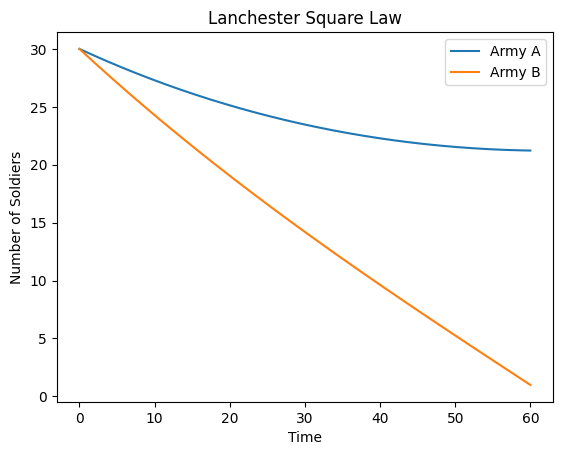

In [6]:
plt.plot(t, X[:, 0], label='Army A')
plt.plot(t, X[:, 1], label='Army B')
plt.xlabel('Time')
plt.ylabel('Number of Soldiers')
plt.title('Lanchester Square Law')
plt.legend()

plt.show()

## 2. Clean, derivative and noisy data

- `X_dot`: exact derivatives, from the true right-hand side.
- `X_noise`: Gaussian noise with $\sigma = 1$ added to $A$ only ($\approx 3$–$4\,\%$ of the signal). $B$ stays clean.

In [7]:
np.random.seed(42)
A_t = X[:,0]

A_t_noise = A_t + np.random.normal(0, size = A_t.shape)

B_t = X[:,1]

X_dot = np.array([-k1*B_t, -k2*A_t]).T
X_squared = X**2
X_noise = np.array([A_t_noise, B_t]).T

In [8]:
X_dot.shape

(1000, 2)

### Checking the conserved quantity

The two weighted squared forces decrease together while their difference $k_2A^2 - k_1B^2$ stays flat at 9 — a numerical confirmation of the square law.

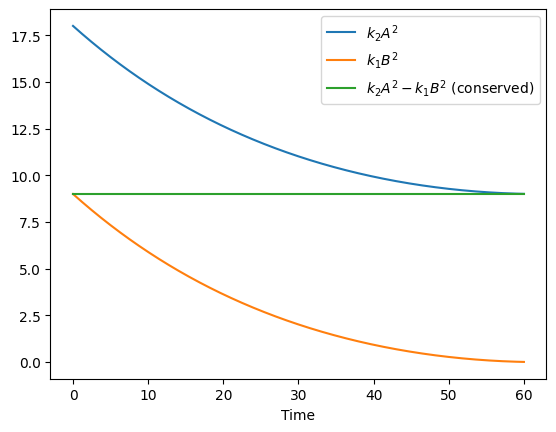

In [9]:
plt.plot(t, k2*X_squared[:,0], label='$k_2 A^2$')
plt.plot(t, k1*X_squared[:,1], label='$k_1 B^2$')
plt.plot(t, k2*X_squared[:,0]-k1*X_squared[:,1], label='$k_2 A^2 - k_1 B^2$ (conserved)')
plt.xlabel('Time')
plt.legend()
plt.show()

## 3. Four SINDy fits

All four use a degree-2 polynomial library $\{1, A, B, A^2, AB, B^2\}$ and STLSQ with threshold 0.001:

| model | data | derivative |
|---|---|---|
| `model_dot` | clean | exact (`x_dot=X_dot`) |
| `model` | clean | finite differences |
| `model_noise` | noisy $A$ | finite differences |
| `model_noise_smoothed` | Savitzky–Golay-smoothed $A$ | smoothed finite differences |

(The print labels were swapped in the original version; `model_dot` is the one given exact derivatives.)

In [10]:
from pysindy.differentiation import SmoothedFiniteDifference


model_dot = ps.SINDy(feature_library=ps.PolynomialLibrary(degree = 2),
                      optimizer=ps.STLSQ(threshold = 0.001))
model = ps.SINDy(feature_library=ps.PolynomialLibrary(degree = 2),
                  optimizer=ps.STLSQ(threshold = 0.001))
model_noise = ps.SINDy(feature_library=ps.PolynomialLibrary(degree = 2), 
                       optimizer=ps.STLSQ(threshold = 0.001))

model_noise_smoothed = ps.SINDy(feature_library=ps.PolynomialLibrary(degree = 2), 
                       optimizer=ps.STLSQ(threshold = 0.001),
                       differentiation_method=SmoothedFiniteDifference())


model_dot.fit(X, t=t,x_dot=X_dot)
model.fit(X, t=t)
model_noise.fit(X_noise, t=t)

from scipy.signal import savgol_filter
smoothed = savgol_filter(A_t_noise, window_length=11, polyorder=3)
model_noise_smoothed.fit(np.array([smoothed,B_t]).T, t=t)

,optimizer,STLSQ(threshold=0.001)
,feature_library,PolynomialLibrary()
,differentiation_method,SmoothedFiniteDifference()
,degree,2
,include_interaction,True
,interaction_only,False
,include_bias,True
,order,'C'
,threshold,0.001
,alpha,0.05
,max_iter,20


In [11]:
print("Model given exact derivatives:")
model_dot.print()
print("\n")
print("Model estimating derivative (finite differences):")
model.print()
print("\n")
print("Model estimating derivative with noise:")
model_noise.print()
print("\n")
print("Model estimating derivative with smoothed noise:")
model_noise_smoothed.print()

Model given exact derivatives:
(x0)' = -0.010 x1
(x1)' = -0.020 x0


Model estimating derivative (finite differences):
(x0)' = -0.010 x1
(x1)' = -0.020 x0


Model estimating derivative with noise:
(x0)' = -44.003 1 +  4.133 x0 + -0.800 x1 + -0.096 x0^2 +  0.033 x0 x1
(x1)' = -0.306 1 + -0.004 x0 + -0.005 x1


Model estimating derivative with smoothed noise:
(x0)' =  0.615 1 + -0.031 x0 + -0.001 x1
(x1)' = -0.142 1 + -0.013 x0 + -0.002 x1


In [12]:
model.coefficients()

array([[ 0.  ,  0.  , -0.01,  0.  ,  0.  ,  0.  ],
       [ 0.  , -0.02,  0.  ,  0.  ,  0.  ,  0.  ]])

In [13]:
k1,k2

(0.01, 0.02)

## 4. Why the noisy fits fail

With clean data SINDy recovers $k_1 = 0.01$ and $k_2 = 0.02$ exactly, both with exact and with estimated derivatives. With noise it fails completely — even for $\dot B$, although $B$ itself is noise-free. There are three compounding reasons:

1. **Differentiation amplifies noise.** Differentiating noise of std $\sigma$ with step $\Delta t \approx 0.06$ gives derivative noise of order $\sigma/\Delta t \approx 10$, while the true $|\dot A|$ is only $\approx 0.15$. The signal-to-noise ratio of the target is below $1/50$. A window of 11 samples in the Savitzky–Golay filter is far too short to fix this.
2. **Errors in the library, not just the target.** The noisy $A$ also appears as a *column* of $\Theta$. That is why the $\dot B$ equation breaks too (errors-in-variables bias).
3. **Weak identifiability from a single trajectory.** Both forces decrease smoothly and monotonically, so over one engagement $1, A, B, A^2, AB, B^2$ are close to linearly dependent. Many coefficient combinations fit almost equally well. The threshold has to stay below the true coefficients (0.01–0.02), so spurious terms of similar size survive.

The plot below shows how little of the noise the short smoothing window removes.

In [14]:
diff_method = SmoothedFiniteDifference()
A_dot_smooth = diff_method(A_t_noise, t)

from scipy.signal import savgol_filter

smoothed = savgol_filter(A_t_noise, window_length=11, polyorder=3)

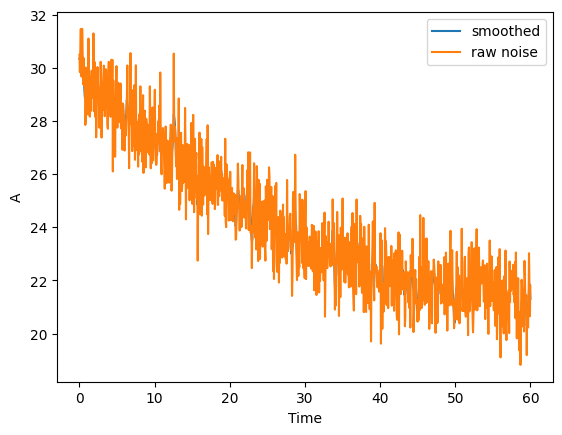

In [15]:
plt.plot(t, smoothed, label='smoothed')
plt.plot(t,A_t_noise, label = 'raw noise')
plt.legend()
plt.xlabel('Time')
plt.ylabel('A')
plt.show()

## 5. A fit that works with noise

Addressing points 1 and 3 is enough here: a **wider smoothing window** (101 samples) for the derivative, and a **smaller library** restricted to linear terms without a constant, which is well conditioned on a single trajectory.

In [16]:
model_fix = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=1, include_bias=False),
    optimizer=ps.STLSQ(threshold=0.005),
    differentiation_method=SmoothedFiniteDifference(smoother_kws={'window_length': 101}),
)
model_fix.fit(X_noise, t=t, feature_names=['A', 'B'])
model_fix.print()

(A)' = -0.011 B
(B)' = -0.020 A


**Result.** Roughly $\dot A = -0.011\,B$, $\dot B = -0.020\,A$: correct structure, with $k_1$ about 10 % off because of the noise. Restricting the library is, however, using prior knowledge — in the thesis setting the library cannot be chosen by looking at the answer.

## Takeaways and possible next steps

- On clean data, SINDy recovers the square law exactly; the challenge is entirely in **noise and identifiability**.
- More informative data is the principled fix: **multiple engagements** with different $(A_0, B_0)$ (pass a list of trajectories to `model.fit`), which breaks the near-collinearity of the library.
- Other options to try: `normalize_columns=True` in STLSQ (columns like $A^2 \sim 900$ and $1$ differ by orders of magnitude), sweeping the threshold and picking the elbow of the error–sparsity Pareto curve (Brunton et al. §3.2), better derivative estimators (total-variation regularisation, `ps.SmoothedFiniteDifference` tuning), and weak/integral SINDy (`ps.WeakPDELibrary`), which avoids pointwise differentiation.
- Model discrimination: fit the **linear law** ($\dot A = -k_1 AB$, $\dot B = -k_2 AB$) on the same data and check whether the library correctly prefers $B$ over $AB$ — a key question when the true attrition mechanism in a simulator is unknown.